# Error Analysis — RAG-Driven Data Cleaning

This notebook analyses prediction errors across three patterns:
1. **Where RAG helps** — LLM-only wrong, RAG-full-k3 correct
2. **Where RAG-full-k5 still fails** — both LLM-only and RAG-full-k5 wrong
3. **Where LLM-only beats RAG** — LLM-only correct, RAG-full-k3 wrong

## 1. Load Results & Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Load experiment 3 results
llm      = pd.read_csv("results_exp3_llm_only.csv")
rag_k3   = pd.read_csv("results_exp3_rag_full_k3.csv")
rag_k5   = pd.read_csv("results_exp3_rag_full_k5.csv")

# Load original dataset and knowledge base
df1 = pd.read_json("normalized_products/dataset_1_normalized.json")
df2 = pd.read_json("normalized_products/dataset_2_normalized.json")
df3 = pd.read_json("normalized_products/dataset_3_normalized.json")
df4 = pd.read_json("normalized_products/dataset_4_normalized.json")
kb  = pd.concat([df2, df3, df4], ignore_index=True)

TARGET_ATTRIBUTES = [
    "model_number", "bus_type", "interface_type",
    "form_factor", "storage_connection_type"
]

print(f"LLM-only tasks:    {len(llm)}")
print(f"RAG-full-k3 tasks: {len(rag_k3)}")
print(f"RAG-full-k5 tasks: {len(rag_k5)}")

LLM-only tasks:    627
RAG-full-k3 tasks: 627
RAG-full-k5 tasks: 627


## 2. Merge Results for Comparison

In [2]:
# Merge all configs on df1_idx + attribute
merged = llm[["df1_idx", "attribute", "ground_truth", "predicted", "correct"]].copy()
merged = merged.rename(columns={"predicted": "pred_llm", "correct": "correct_llm"})

merged = merged.merge(
    rag_k3[["df1_idx", "attribute", "predicted", "correct"]].rename(
        columns={"predicted": "pred_rag_k3", "correct": "correct_rag_k3"}),
    on=["df1_idx", "attribute"]
)
merged = merged.merge(
    rag_k5[["df1_idx", "attribute", "predicted", "correct"]].rename(
        columns={"predicted": "pred_rag_k5", "correct": "correct_rag_k5"}),
    on=["df1_idx", "attribute"]
)

# Label each row with its error pattern
def label_pattern(row):
    if not row["correct_llm"] and row["correct_rag_k3"]:
        return "RAG_helps"
    elif not row["correct_llm"] and not row["correct_rag_k5"]:
        return "both_fail"
    elif row["correct_llm"] and not row["correct_rag_k3"]:
        return "LLM_wins"
    elif row["correct_llm"] and row["correct_rag_k3"]:
        return "both_correct"
    else:
        return "other"

merged["pattern"] = merged.apply(label_pattern, axis=1)

print("Overall pattern distribution:")
print(merged["pattern"].value_counts())
print()
print("Pattern distribution per attribute:")
print(merged.groupby(["attribute", "pattern"]).size().unstack(fill_value=0))

Overall pattern distribution:
pattern
both_fail       218
both_correct    158
RAG_helps       151
other            60
LLM_wins         40
Name: count, dtype: int64

Pattern distribution per attribute:
pattern                  LLM_wins  RAG_helps  both_correct  both_fail  other
attribute                                                                   
bus_type                       19         21           100          6      8
form_factor                     2         21             5         26      7
interface_type                  3         13            25         19      4
model_number                   11         84             9        157     41
storage_connection_type         5         12            19         10      0


## 3. Pattern Overview — Stacked Bar Chart

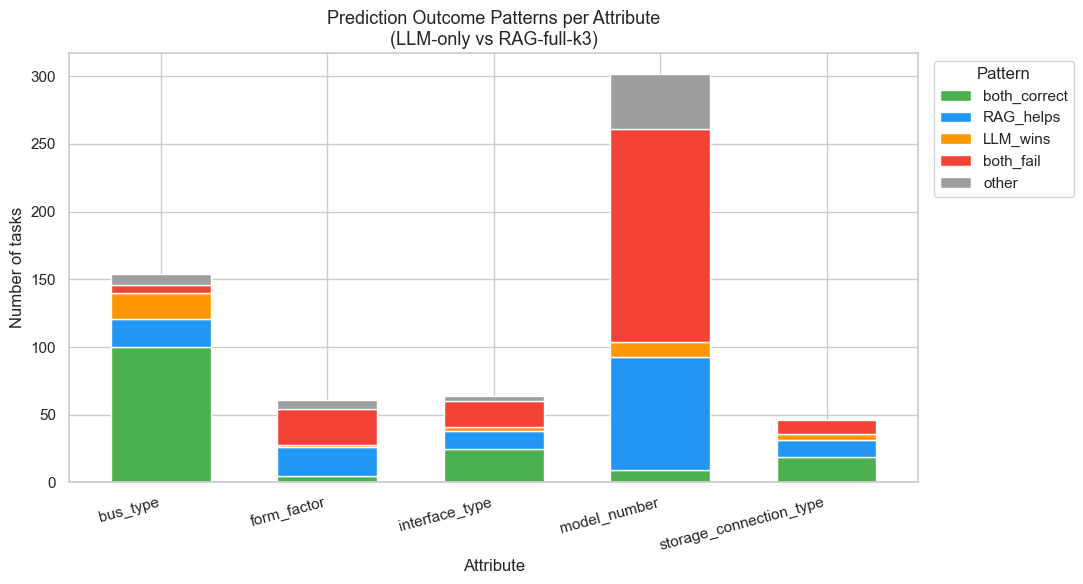

In [3]:
pattern_counts = merged.groupby(["attribute", "pattern"]).size().unstack(fill_value=0)
# Reorder columns for visual clarity
col_order = [c for c in ["both_correct", "RAG_helps", "LLM_wins", "both_fail", "other"]
             if c in pattern_counts.columns]
pattern_counts = pattern_counts[col_order]

colors = {"both_correct": "#4CAF50", "RAG_helps": "#2196F3",
          "LLM_wins": "#FF9800", "both_fail": "#F44336", "other": "#9E9E9E"}
bar_colors = [colors.get(c, "#9E9E9E") for c in col_order]

ax = pattern_counts.plot(kind="bar", stacked=True, figsize=(11, 6),
                         color=bar_colors, edgecolor="white", width=0.6)
ax.set_xlabel("Attribute", fontsize=12)
ax.set_ylabel("Number of tasks", fontsize=12)
ax.set_title("Prediction Outcome Patterns per Attribute\n(LLM-only vs RAG-full-k3)", fontsize=13)
ax.legend(title="Pattern", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("fig_error_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Pattern 1 — Where RAG Helps (LLM wrong, RAG-k3 correct)

In [4]:
rag_helps = merged[merged["pattern"] == "RAG_helps"].copy()
print(f"RAG helps in {len(rag_helps)} cases ({100*len(rag_helps)/len(merged):.1f}% of all tasks)")
print()
print("By attribute:")
print(rag_helps["attribute"].value_counts())
print()
print("LLM wrong predictions (most common mistakes):")
for attr in TARGET_ATTRIBUTES:
    sub = rag_helps[rag_helps["attribute"] == attr]
    if len(sub) == 0:
        continue
    print(f"\n  [{attr}] — {len(sub)} cases")
    top_wrong = sub["pred_llm"].value_counts().head(5)
    for val, cnt in top_wrong.items():
        print(f"    LLM predicted: '{val}' ({cnt}x)")

RAG helps in 151 cases (24.1% of all tasks)

By attribute:
attribute
model_number               84
bus_type                   21
form_factor                21
interface_type             13
storage_connection_type    12
Name: count, dtype: int64

LLM wrong predictions (most common mistakes):

  [model_number] — 84 cases
    LLM predicted: 'Aorus XC' (1x)
    LLM predicted: 'NMV200GA3F' (1x)
    LLM predicted: 'WDBS1402J0B-01' (1x)
    LLM predicted: 'ST120VF010' (1x)
    LLM predicted: 'VCG70216' (1x)

  [bus_type] — 21 cases
    LLM predicted: 'M.2' (5x)
    LLM predicted: 'SATA' (5x)
    LLM predicted: 'NVMe' (3x)
    LLM predicted: 'NVIDIA' (2x)
    LLM predicted: 'Xpand' (1x)

  [interface_type] — 13 cases
    LLM predicted: 'USB_A' (3x)
    LLM predicted: 'USB' (2x)
    LLM predicted: 'M.2' (2x)
    LLM predicted: 'USB 3.2 Gen 1' (1x)
    LLM predicted: 'M.2, PCIe' (1x)

  [form_factor] — 21 cases
    LLM predicted: 'Portable' (8x)
    LLM predicted: 'M.2' (4x)
    LLM predicted: '

In [5]:
# Show 5 concrete examples where RAG helps, for model_number
print("=== CONCRETE EXAMPLES: RAG helps for model_number ===")
examples = rag_helps[rag_helps["attribute"] == "model_number"].head(5)
for _, row in examples.iterrows():
    product_row = df1.loc[row["df1_idx"]]
    print(f"\nProduct: {product_row.get('title', 'N/A')[:80]}")
    print(f"  Ground truth:  '{row['ground_truth']}'")
    print(f"  LLM-only:      '{row['pred_llm']}'  ✗")
    print(f"  RAG-full-k3:   '{row['pred_rag_k3']}'  ✓")

=== CONCRETE EXAMPLES: RAG helps for model_number ===

Product: Gigabyte NVIDIA GeForce RTX 3080 Gaming OC 10GB Ampere Graphics Card
  Ground truth:  'GV-N3080GAMING OC-10GD'
  LLM-only:      'Aorus XC'  ✗
  RAG-full-k3:   'GV-N3080GAMING OC-10GD'  ✓

Product: AMD RADEON PRO WX 4100 4 GB GDDR5
  Ground truth:  '100-506008'
  LLM-only:      'WX-4100'  ✗
  RAG-full-k3:   '100-506008'  ✓

Product: Patriot Burst 240GB 2.5\\
  Ground truth:  'PBU240GS25SSDR'
  LLM-only:      'PBT240B250S'  ✗
  RAG-full-k3:   'PBU240GS25SSDR'  ✓

Product: Kingston Technology DataTraveler 100 G3 USB flash drive 256 GB USB Type-A 3.2 Ge
  Ground truth:  'DT100G3/256GB'
  LLM-only:      'AID256GB/DT100G3'  ✗
  RAG-full-k3:   'DT100G3'  ✓

Product: Gigabyte AORUS 1TB M.2 PCIe 4.0 x4 NVMe SSD/Solid State Drive
  Ground truth:  'GP-ASM2NE6100TTTD'
  LLM-only:      'AORUS1TB'  ✗
  RAG-full-k3:   'GP-ASM2NE6100TTTD'  ✓


## 5. Pattern 2 — Where RAG-full-k5 Still Fails (both wrong)

In [6]:
both_fail = merged[merged["pattern"] == "both_fail"].copy()
print(f"Both fail in {len(both_fail)} cases ({100*len(both_fail)/len(merged):.1f}% of all tasks)")
print()
print("By attribute:")
print(both_fail["attribute"].value_counts())
print()

# Analyse why RAG-k5 still fails — look at what it predicted vs ground truth
for attr in TARGET_ATTRIBUTES:
    sub = both_fail[both_fail["attribute"] == attr]
    if len(sub) == 0:
        continue
    print(f"\n  [{attr}] — {len(sub)} persistent failures")
    print(f"  Most common RAG-k5 wrong predictions:")
    top_wrong = sub["pred_rag_k5"].value_counts().head(5)
    for val, cnt in top_wrong.items():
        print(f"    '{val}' ({cnt}x)")
    print(f"  Most common ground truth values in failures:")
    top_gt = sub["ground_truth"].value_counts().head(5)
    for val, cnt in top_gt.items():
        print(f"    '{val}' ({cnt}x)")

Both fail in 218 cases (34.8% of all tasks)

By attribute:
attribute
model_number               157
form_factor                 26
interface_type              19
storage_connection_type     10
bus_type                     6
Name: count, dtype: int64


  [model_number] — 157 persistent failures
  Most common RAG-k5 wrong predictions:
    'GV-N166SQC-6GD' (1x)
    'TUF GAMING GEFORCE GTX 1660 SUPER 6GB TUF GAMING' (1x)
    'ST2000NM0006' (1x)
    'ST6000NM0055' (1x)
    'ST2000NX0274' (1x)
  Most common ground truth values in failures:
    'CZ73' (2x)
    'GV-N166SOC-6GD' (1x)
    'TUF-GTX1660S-6G-GAMING' (1x)
    'ST2000NX0253' (1x)
    'ST1000NX0313' (1x)

  [bus_type] — 6 persistent failures
  Most common RAG-k5 wrong predictions:
    'M.2' (1x)
    'PCIe 3.0 x16' (1x)
    'SATA III' (1x)
    'SATA' (1x)
    'USB-C' (1x)
  Most common ground truth values in failures:
    'SATA III' (1x)
    'PCIe x16' (1x)
    'USB 3.0' (1x)
    'SAS 12G' (1x)
    'USB 3.1' (1x)

  [interface_type] — 

In [7]:
# Show 5 concrete persistent failure examples for model_number
print("=== CONCRETE EXAMPLES: Persistent failures for model_number ===")
examples = both_fail[both_fail["attribute"] == "model_number"].head(5)
for _, row in examples.iterrows():
    product_row = df1.loc[row["df1_idx"]]
    print(f"\nProduct: {product_row.get('title', 'N/A')[:80]}")
    print(f"  Ground truth:  '{row['ground_truth']}'")
    print(f"  LLM-only:      '{row['pred_llm']}'  ✗")
    print(f"  RAG-full-k5:   '{row['pred_rag_k5']}'  ✗")
    # Show the cluster_id to inspect KB coverage
    cluster = product_row.get("cluster_id")
    kb_matches = kb[kb["cluster_id"] == cluster][["title", "model_number"]].dropna(subset=["model_number"])
    print(f"  KB matches (cluster_id={cluster}):")
    for _, km in kb_matches.head(3).iterrows():
        print(f"    '{km['model_number']}' — {str(km['title'])[:60]}")

=== CONCRETE EXAMPLES: Persistent failures for model_number ===

Product: Gigabyte GeForce GTX 1660 SUPER OC 6GB Dual Fan Graphics Card
  Ground truth:  'GV-N166SOC-6GD'
  LLM-only:      'GV-N166SUPER-6GD'  ✗
  RAG-full-k5:   'GV-N166SQC-6GD'  ✗
  KB matches (cluster_id=1028734):
    'GV-N166SOC-6GD' — Gigabyte GV-N166SOC-6GD graphics card NVIDIA GeForce GTX 166

Product: MSI GeForce GTX 1660 Ti GAMING X 6GB GDDR6 Graphics Card
  Ground truth:  'V375-040R'
  LLM-only:      'GeForce GTX 1660 Ti GAMING X 6G'  ✗
  RAG-full-k5:   '912-V375-040'  ✗
  KB matches (cluster_id=1029916):
    'V375-040R' — MSI V375-040R grafikkort GeForce GTX 1660 Ti 6 GB GDDR6
    '912-V375-040' — MSI GeForce GTX 1660 Ti GAMING X 6G PCI Express x16 3.0 6GB 

Product: Asus Strix GeForce RTX 2060 Super EVO OC Gaming 8GB Graphics Card
  Ground truth:  '90YV0DQ0-M0NA00'
  LLM-only:      'Twin Frozr II'  ✗
  RAG-full-k5:   'TBC (To Be Confirmed, as the exact model number is not provided in the reference products)'  ✗

## 6. Pattern 3 — Where LLM-only Wins (LLM correct, RAG-k3 wrong)

In [8]:
llm_wins = merged[merged["pattern"] == "LLM_wins"].copy()
print(f"LLM wins in {len(llm_wins)} cases ({100*len(llm_wins)/len(merged):.1f}% of all tasks)")
print()
print("By attribute:")
print(llm_wins["attribute"].value_counts())
print()

# What did RAG predict wrongly here?
for attr in TARGET_ATTRIBUTES:
    sub = llm_wins[llm_wins["attribute"] == attr]
    if len(sub) == 0:
        continue
    print(f"\n  [{attr}] — {len(sub)} cases where RAG misleads")
    print(f"  RAG-k3 wrong predictions:")
    top_wrong = sub["pred_rag_k3"].value_counts().head(5)
    for val, cnt in top_wrong.items():
        print(f"    '{val}' ({cnt}x)")

LLM wins in 40 cases (6.4% of all tasks)

By attribute:
attribute
bus_type                   19
model_number               11
storage_connection_type     5
interface_type              3
form_factor                 2
Name: count, dtype: int64


  [model_number] — 11 cases where RAG misleads
  RAG-k3 wrong predictions:
    'GT710-2GD3H(LP)' (1x)
    'MZ-75E500BW' (1x)
    'GV-N207SWF3OC-8GD' (1x)
    'MZ-N6E1T0YCH' (1x)
    'PWE10.6250' (1x)

  [bus_type] — 19 cases where RAG misleads
  RAG-k3 wrong predictions:
    'PCIe 3.0 x8' (5x)
    'GDDR6' (3x)
    'USB 2.0' (2x)
    'PCIe 4.0' (1x)
    'NVLink' (1x)

  [interface_type] — 3 cases where RAG misleads
  RAG-k3 wrong predictions:
    'USB 3.1 Gen 2' (1x)
    'USB 3.0' (1x)
    'USB-Type-C' (1x)

  [form_factor] — 2 cases where RAG misleads
  RAG-k3 wrong predictions:
    '2.5' (1x)
    '7mm' (1x)

  [storage_connection_type] — 5 cases where RAG misleads
  RAG-k3 wrong predictions:
    'USB-A' (1x)
    '2.5Inches SAS Dual Port' (1x)
  

In [9]:
# Show 5 concrete examples where RAG misleads
print("=== CONCRETE EXAMPLES: LLM wins (RAG misleads) ===")
# Pick the most interesting attribute — where LLM_wins count is highest
best_attr = llm_wins["attribute"].value_counts().idxmax()
examples = llm_wins[llm_wins["attribute"] == best_attr].head(5)
print(f"Showing examples for attribute: {best_attr}")
for _, row in examples.iterrows():
    product_row = df1.loc[row["df1_idx"]]
    print(f"\nProduct: {product_row.get('title', 'N/A')[:80]}")
    print(f"  Ground truth:  '{row['ground_truth']}'")
    print(f"  LLM-only:      '{row['pred_llm']}'  ✓")
    print(f"  RAG-full-k3:   '{row['pred_rag_k3']}'  ✗")

=== CONCRETE EXAMPLES: LLM wins (RAG misleads) ===
Showing examples for attribute: bus_type

Product: Asus GeForce GTX 1650 DUAL OC 4GB GDDR5 Graphics Card
  Ground truth:  'PCIe 3.0 x16'
  LLM-only:      'X16'  ✓
  RAG-full-k3:   'PCIe 4.0'  ✗

Product: Kingston 16GB DataTraveler Vault Flash Drive
  Ground truth:  'USB 3.0'
  LLM-only:      'USB'  ✓
  RAG-full-k3:   'USB 2.0'  ✗

Product: Asus Strix GeForce RTX 2060 Super EVO OC Gaming 8GB Graphics Card
  Ground truth:  'PCIe 4.0'
  LLM-only:      'PCIe'  ✓
  RAG-full-k3:   'NVLink'  ✗

Product: AMD RADEON PRO WX 4100 4 GB GDDR5
  Ground truth:  'PCIe 3.0 x16'
  LLM-only:      'PCIe'  ✓
  RAG-full-k3:   'PCIe 3.0 x8'  ✗

Product: ASUS GeForce RTX 2080 Ti 11GB Strix Edition Boost Graphics Card
  Ground truth:  'PCIe 3.0 x16'
  LLM-only:      'PCIe'  ✓
  RAG-full-k3:   'NVIDIA'  ✗


## 7. Retrieval Quality Analysis
### Do retrieved candidates actually contain the correct answer?

In [10]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def row_to_text(row):
    attrs = ["title", "model", "model_number", "brand", "product_type"]
    return " | ".join([str(row[a]) for a in attrs if pd.notna(row.get(a))])

print("Encoding knowledge base...")
kb["_text"] = kb.apply(row_to_text, axis=1)
kb_embeddings = model.encode(kb["_text"].tolist(), convert_to_tensor=True,
                              batch_size=64, show_progress_bar=True)
print("Done.")

/opt/anaconda3/envs/pydi_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Encoding knowledge base...


Batches: 100%|██████████| 35/35 [00:03<00:00, 10.80it/s]

Done.


In [11]:
def normalize(val):
    return str(val).lower().strip()

def gt_in_candidates(row, attribute, top_k=3):
    """Check if ground truth value appears in the top-k retrieved candidates."""
    product_row = df1.loc[row["df1_idx"]]
    q_text = row_to_text(product_row)
    q_emb = model.encode(q_text, convert_to_tensor=True)
    scores = util.cos_sim(q_emb, kb_embeddings)[0]
    top_indices = np.argsort(-scores.cpu().numpy())[:top_k]
    candidates = kb.iloc[top_indices]
    gt = normalize(row["ground_truth"])
    for _, c in candidates.iterrows():
        val = c.get(attribute)
        if pd.notna(val):
            v = normalize(str(val))
            if v == gt or v in gt or gt in v:
                return True
    return False

# Sample 50 rows per attribute for retrieval quality check (full run takes a while)
retrieval_results = []
for attr in TARGET_ATTRIBUTES:
    attr_rows = merged[merged["attribute"] == attr].sample(
        n=min(50, len(merged[merged["attribute"] == attr])), random_state=42
    )
    hit = 0
    for _, row in attr_rows.iterrows():
        if gt_in_candidates(row, attr, top_k=3):
            hit += 1
    recall = hit / len(attr_rows)
    retrieval_results.append({"attribute": attr, "recall@3": recall, "n": len(attr_rows)})
    print(f"{attr}: recall@3 = {recall:.3f} ({hit}/{len(attr_rows)})")

retrieval_df = pd.DataFrame(retrieval_results)

model_number: recall@3 = 0.360 (18/50)
bus_type: recall@3 = 0.720 (36/50)
interface_type: recall@3 = 0.720 (36/50)
form_factor: recall@3 = 0.580 (29/50)
storage_connection_type: recall@3 = 0.652 (30/46)


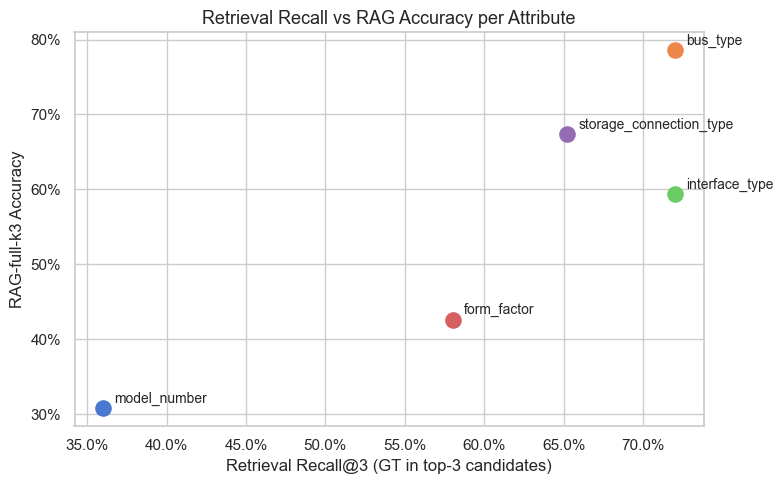


Retrieval quality summary:
              attribute  recall@3  rag_k3_accuracy
           model_number  0.360000         0.307947
               bus_type  0.720000         0.785714
         interface_type  0.720000         0.593750
            form_factor  0.580000         0.426230
storage_connection_type  0.652174         0.673913


In [12]:
# Plot recall@3 vs RAG-k3 accuracy
rag_k3_acc = rag_k3.groupby("attribute")["correct"].mean().reset_index()
rag_k3_acc.columns = ["attribute", "rag_k3_accuracy"]
comparison = retrieval_df.merge(rag_k3_acc, on="attribute")

fig, ax = plt.subplots(figsize=(8, 5))
colors_list = sns.color_palette("muted", len(comparison))
for i, row in comparison.iterrows():
    ax.scatter(row["recall@3"], row["rag_k3_accuracy"],
               s=120, color=colors_list[i], zorder=5)
    ax.annotate(row["attribute"],
                (row["recall@3"], row["rag_k3_accuracy"]),
                textcoords="offset points", xytext=(8, 4), fontsize=10)

ax.set_xlabel("Retrieval Recall@3 (GT in top-3 candidates)", fontsize=12)
ax.set_ylabel("RAG-full-k3 Accuracy", fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Retrieval Recall vs RAG Accuracy per Attribute", fontsize=13)
plt.tight_layout()
plt.savefig("fig_retrieval_recall_vs_accuracy.png", dpi=150)
plt.show()

print("\nRetrieval quality summary:")
print(comparison[["attribute", "recall@3", "rag_k3_accuracy"]].to_string(index=False))

## 8. Summary Table — All Error Patterns

In [13]:
summary = merged.groupby(["attribute", "pattern"]).size().unstack(fill_value=0)
summary["total"] = summary.sum(axis=1)
for col in ["both_correct", "RAG_helps", "LLM_wins", "both_fail"]:
    if col in summary.columns:
        summary[f"{col}_%"] = (summary[col] / summary["total"] * 100).round(1)

print("=== ERROR ANALYSIS SUMMARY ===")
print(summary.to_string())
summary.to_csv("error_analysis_summary.csv")
print("\nSaved to error_analysis_summary.csv")

=== ERROR ANALYSIS SUMMARY ===
pattern                  LLM_wins  RAG_helps  both_correct  both_fail  other  total  both_correct_%  RAG_helps_%  LLM_wins_%  both_fail_%
attribute                                                                                                                                
bus_type                       19         21           100          6      8    154            64.9         13.6        12.3          3.9
form_factor                     2         21             5         26      7     61             8.2         34.4         3.3         42.6
interface_type                  3         13            25         19      4     64            39.1         20.3         4.7         29.7
model_number                   11         84             9        157     41    302             3.0         27.8         3.6         52.0
storage_connection_type         5         12            19         10      0     46            41.3         26.1        10.9         21.7

Sa